In [2]:
import pandas as pd
import numpy as np

In [3]:
CSV_A = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_mesmer_beforeREDSEA_gnn_predict.csv"
CSV_B = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_mesmer_afterREDSEA_gnn_predict.csv"

CLUSTER_COL = "leiden"
CELLTYPE_COL = "pred_name"
SLIDE_COL = "slide_name"   


FORCE_STRING_IDS = True

In [4]:
CLUSTER = "leiden"
CTYPE   = "pred_name"
SLIDE   = "slide_name"
CELLID  = "CellID"
XCOL    = "x_centroid"
YCOL    = "y_centroid"

In [5]:
def load_minimal(csv_path):
    df = pd.read_csv(csv_path)

    keep = [SLIDE, CELLID, CLUSTER, CTYPE]
    # coords optional for diagnostics / fallback matching
    for c in [XCOL, YCOL]:
        if c in df.columns:
            keep.append(c)

    missing = [c for c in [SLIDE, CELLID, CLUSTER, CTYPE] if c not in df.columns]
    if missing:
        raise ValueError(f"{csv_path} missing required columns: {missing}")

    df = df[keep].copy()
    df = df.dropna(subset=[SLIDE, CELLID, CLUSTER, CTYPE])

    # Normalize datatypes
    df[SLIDE] = df[SLIDE].astype(str)
    df[CELLID] = df[CELLID].astype(str)
    df[CLUSTER] = df[CLUSTER].astype(str)
    df[CTYPE] = df[CTYPE].astype(str)

    return df

A = load_minimal(CSV_A)
B = load_minimal(CSV_B)

# If CellID is only unique within slide, join on both.
merged = A.merge(
    B,
    on=[SLIDE, CELLID],
    how="inner",
    suffixes=("_A", "_B")
)

print("A cells:", len(A))
print("B cells:", len(B))
print("Matched cells (inner join):", len(merged))
print("Match rate A:", len(merged) / len(A))
print("Match rate B:", len(merged) / len(B))

# Quick sanity checks
dupsA = A.duplicated(subset=[SLIDE, CELLID]).sum()
dupsB = B.duplicated(subset=[SLIDE, CELLID]).sum()
print("Duplicate (slide, CellID) in A:", dupsA)
print("Duplicate (slide, CellID) in B:", dupsB)

A cells: 162439
B cells: 161867
Matched cells (inner join): 161656
Match rate A: 0.9951797290059653
Match rate B: 0.9986964606745043
Duplicate (slide, CellID) in A: 0
Duplicate (slide, CellID) in B: 0


In [6]:
def cluster_purity_table_from_series(cluster_s, ctype_s):
    df = pd.DataFrame({"cluster": cluster_s.astype(str), "ctype": ctype_s.astype(str)})
    # counts per cluster x celltype
    ct = df.groupby(["cluster", "ctype"]).size().rename("count").reset_index()
    totals = ct.groupby("cluster")["count"].sum().rename("n_cells").reset_index()

    ct_sorted = ct.sort_values(["cluster", "count"], ascending=[True, False])
    top = (ct_sorted.groupby("cluster").head(1)
           .rename(columns={"ctype":"top_celltype", "count":"top_count"})[["cluster","top_celltype","top_count"]])

    n_types = ct.groupby("cluster")["ctype"].nunique().rename("n_celltypes").reset_index()

    # entropy
    ct2 = ct.merge(totals, on="cluster", how="left")
    ct2["p"] = ct2["count"] / ct2["n_cells"]
    ent = (ct2.assign(term=lambda x: np.where(x["p"] > 0, -x["p"] * np.log2(x["p"]), 0.0))
                .groupby("cluster")["term"].sum().rename("entropy").reset_index())

    out = totals.merge(top, on="cluster").merge(n_types, on="cluster").merge(ent, on="cluster")
    out["purity"] = out["top_count"] / out["n_cells"]
    out = out.sort_values(["purity","n_cells"], ascending=[False, False]).reset_index(drop=True)
    return out

purA = cluster_purity_table_from_series(merged[f"{CLUSTER}_A"], merged[f"{CTYPE}_A"])
purB = cluster_purity_table_from_series(merged[f"{CLUSTER}_B"], merged[f"{CTYPE}_B"])

overallA = purA["top_count"].sum() / purA["n_cells"].sum()
overallB = purB["top_count"].sum() / purB["n_cells"].sum()

print(f"Overall weighted purity (matched cells only): A={overallA:.4f}, B={overallB:.4f}, A-B={overallA-overallB:.4f}")

display(purA.head(20))
display(purB.head(20))

Overall weighted purity (matched cells only): A=0.6175, B=0.6220, A-B=-0.0045


,cluster,n_cells,top_celltype,top_count,n_celltypes,entropy,purity
0,38,271,B,270,2,0.035137,0.996310
1,33,2930,Smooth muscle,2852,7,0.217052,0.973379
2,32,1046,Paneth,1011,11,0.310110,0.966539
3,15,4429,Smooth muscle,4273,11,0.294725,0.964778
4,37,653,ITLN+ Epithelial,625,5,0.327780,0.957121
5,30,2010,Smooth muscle,1921,5,0.276274,0.955721
6,10,3220,Nerve,2902,13,0.730344,0.901242
7,34,2948,Smooth muscle,2647,4,0.507802,0.897897
8,18,1092,Neuroendocrine,954,15,0.864116,0.873626
9,28,8267,Plasma,7187,13,0.827845,0.869360


,cluster,n_cells,top_celltype,top_count,n_celltypes,entropy,purity
0,35,242,B,241,2,0.038672,0.995868
1,30,2888,Smooth muscle,2814,9,0.238553,0.974377
2,31,1140,Paneth,1102,12,0.310700,0.966667
3,15,7608,Smooth muscle,7289,17,0.354346,0.958070
4,18,3394,Nerve,3194,13,0.423177,0.941072
5,26,2240,Smooth muscle,2025,10,0.605921,0.904018
6,10,4239,M2 Macrophage,3751,16,0.774519,0.884879
7,2,4202,CD36 low Endothelial,3695,15,0.810616,0.879343
8,22,4701,Plasma,4127,21,0.878333,0.877898
9,25,1102,Neuroendocrine,956,14,0.914304,0.867514


In [7]:
def composition_matrix(cluster_s, ctype_s):
    tab = pd.crosstab(cluster_s.astype(str), ctype_s.astype(str))
    frac = tab.div(tab.sum(axis=1), axis=0)
    return tab, frac

countsA, fracA = composition_matrix(merged[f"{CLUSTER}_A"], merged[f"{CTYPE}_A"])
countsB, fracB = composition_matrix(merged[f"{CLUSTER}_B"], merged[f"{CTYPE}_B"])

# Ensure same columns (cell types) for similarity computations
all_types = sorted(set(fracA.columns) | set(fracB.columns))
fracA = fracA.reindex(columns=all_types, fill_value=0.0)
fracB = fracB.reindex(columns=all_types, fill_value=0.0)

print("Clusters A:", fracA.shape[0], " | Clusters B:", fracB.shape[0], " | Cell types:", len(all_types))

Clusters A: 39  | Clusters B: 36  | Cell types: 28


In [8]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import linear_sum_assignment

sim = cosine_similarity(fracA.values, fracB.values)  # (nA x nB), higher = more similar

# Hungarian solves a MIN cost assignment; use cost = 1 - similarity
cost = 1.0 - sim
row_ind, col_ind = linear_sum_assignment(cost)

match_df = pd.DataFrame({
    "cluster_A": fracA.index[row_ind],
    "cluster_B": fracB.index[col_ind],
    "cosine_similarity": sim[row_ind, col_ind],
})

# Add purities for each matched cluster
purA_map = purA.set_index("cluster")[["n_cells","top_celltype","purity","entropy","n_celltypes"]].add_suffix("_A")
purB_map = purB.set_index("cluster")[["n_cells","top_celltype","purity","entropy","n_celltypes"]].add_suffix("_B")

match_df = (match_df
            .join(purA_map, on="cluster_A")
            .join(purB_map, on="cluster_B"))

match_df["purity_diff_A_minus_B"] = match_df["purity_A"] - match_df["purity_B"]
match_df = match_df.sort_values("cosine_similarity", ascending=False).reset_index(drop=True)

display(match_df.head(30))

,cluster_A,cluster_B,cosine_similarity,n_cells_A,top_celltype_A,purity_A,entropy_A,n_celltypes_A,n_cells_B,top_celltype_B,purity_B,entropy_B,n_celltypes_B,purity_diff_A_minus_B
0,38,35,1.000000,271,B,0.996310,0.035137,2,242,B,0.995868,0.038672,2,0.000442
1,32,31,0.999974,1046,Paneth,0.966539,0.310110,11,1140,Paneth,0.966667,0.310700,12,-0.000127
2,18,25,0.999915,1092,Neuroendocrine,0.873626,0.864116,15,1102,Neuroendocrine,0.867514,0.914304,14,0.006113
3,33,30,0.999913,2930,Smooth muscle,0.973379,0.217052,7,2888,Smooth muscle,0.974377,0.238553,9,-0.000998
4,15,15,0.999868,4429,Smooth muscle,0.964778,0.294725,11,7608,Smooth muscle,0.958070,0.354346,17,0.006707
5,31,34,0.999773,1900,Epithelial,0.628947,1.385109,15,1855,Epithelial,0.642588,1.288208,16,-0.013640
6,19,11,0.999508,4902,CD4+ T,0.815177,1.118944,17,5032,CD4+ T,0.818362,1.149100,20,-0.003185
7,30,26,0.999437,2010,Smooth muscle,0.955721,0.276274,5,2240,Smooth muscle,0.904018,0.605921,10,0.051704
8,10,18,0.999397,3220,Nerve,0.901242,0.730344,13,3394,Nerve,0.941072,0.423177,13,-0.039830
9,24,17,0.999065,1367,PDPN+ Stromal,0.809071,1.121960,11,1630,PDPN+ Stromal,0.752761,1.393749,14,0.056310


In [9]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

leiden_A = merged[f"{CLUSTER}_A"].astype(str).values
leiden_B = merged[f"{CLUSTER}_B"].astype(str).values

ari = adjusted_rand_score(leiden_A, leiden_B)
nmi = normalized_mutual_info_score(leiden_A, leiden_B)

print(f"Leiden agreement on matched cells: ARI={ari:.4f} | NMI={nmi:.4f}")

Leiden agreement on matched cells: ARI=0.4645 | NMI=0.6617


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
def _prep_purity_df(pur_tbl: pd.DataFrame, label: str) -> pd.DataFrame:
    d = pur_tbl.copy()
    d["dataset"] = label
    d["cluster"] = d["cluster"].astype(str)
    d["purity"] = d["purity"].astype(float)
    d["n_cells"] = d["n_cells"].astype(float)
    # keep a stable ordering: by cluster id (string) then n_cells
    return d[["dataset", "cluster", "purity", "n_cells", "top_celltype"]]

purA_plot = _prep_purity_df(purA, "A")
purB_plot = _prep_purity_df(purB, "B")

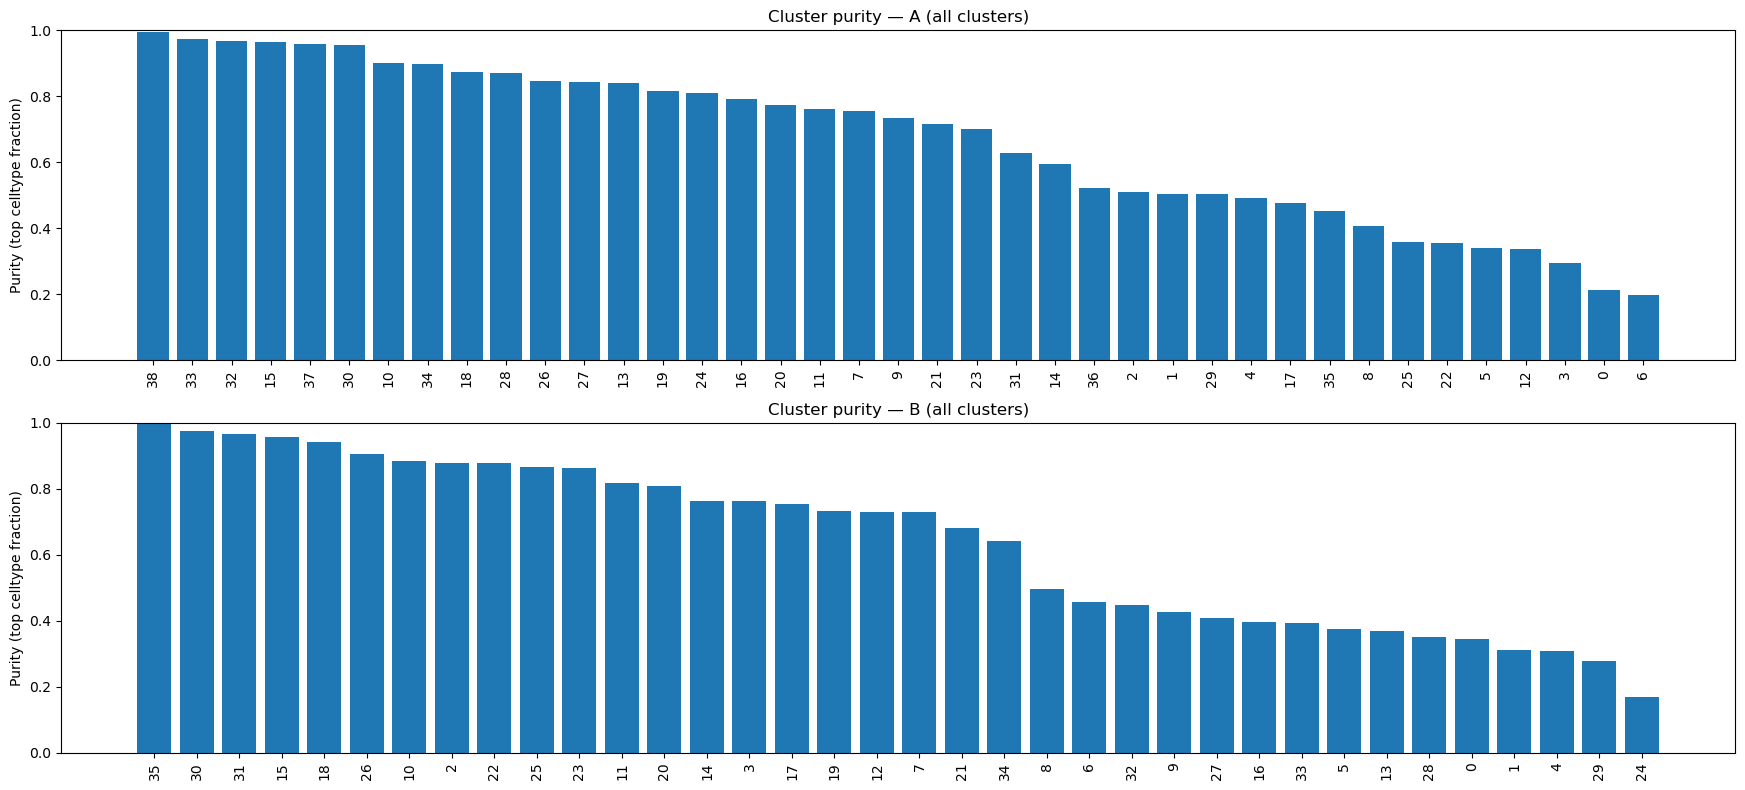

In [12]:
purA_plot_s = purA_plot.sort_values(["purity","n_cells"], ascending=[False, False]).reset_index(drop=True)
purB_plot_s = purB_plot.sort_values(["purity","n_cells"], ascending=[False, False]).reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(max(10, 0.45*max(len(purA_plot_s), len(purB_plot_s))), 8), sharey=True)

# A
ax = axes[0]
ax.bar(purA_plot_s["cluster"].astype(str).values, purA_plot_s["purity"].values)
ax.set_title("Cluster purity — A (all clusters)")
ax.set_ylabel("Purity (top celltype fraction)")
ax.set_ylim(0, 1.0)
ax.tick_params(axis="x", labelrotation=90)

# B
ax = axes[1]
ax.bar(purB_plot_s["cluster"].astype(str).values, purB_plot_s["purity"].values)
ax.set_title("Cluster purity — B (all clusters)")
ax.set_ylabel("Purity (top celltype fraction)")
ax.set_ylim(0, 1.0)
ax.tick_params(axis="x", labelrotation=90)

plt.tight_layout()
plt.show()

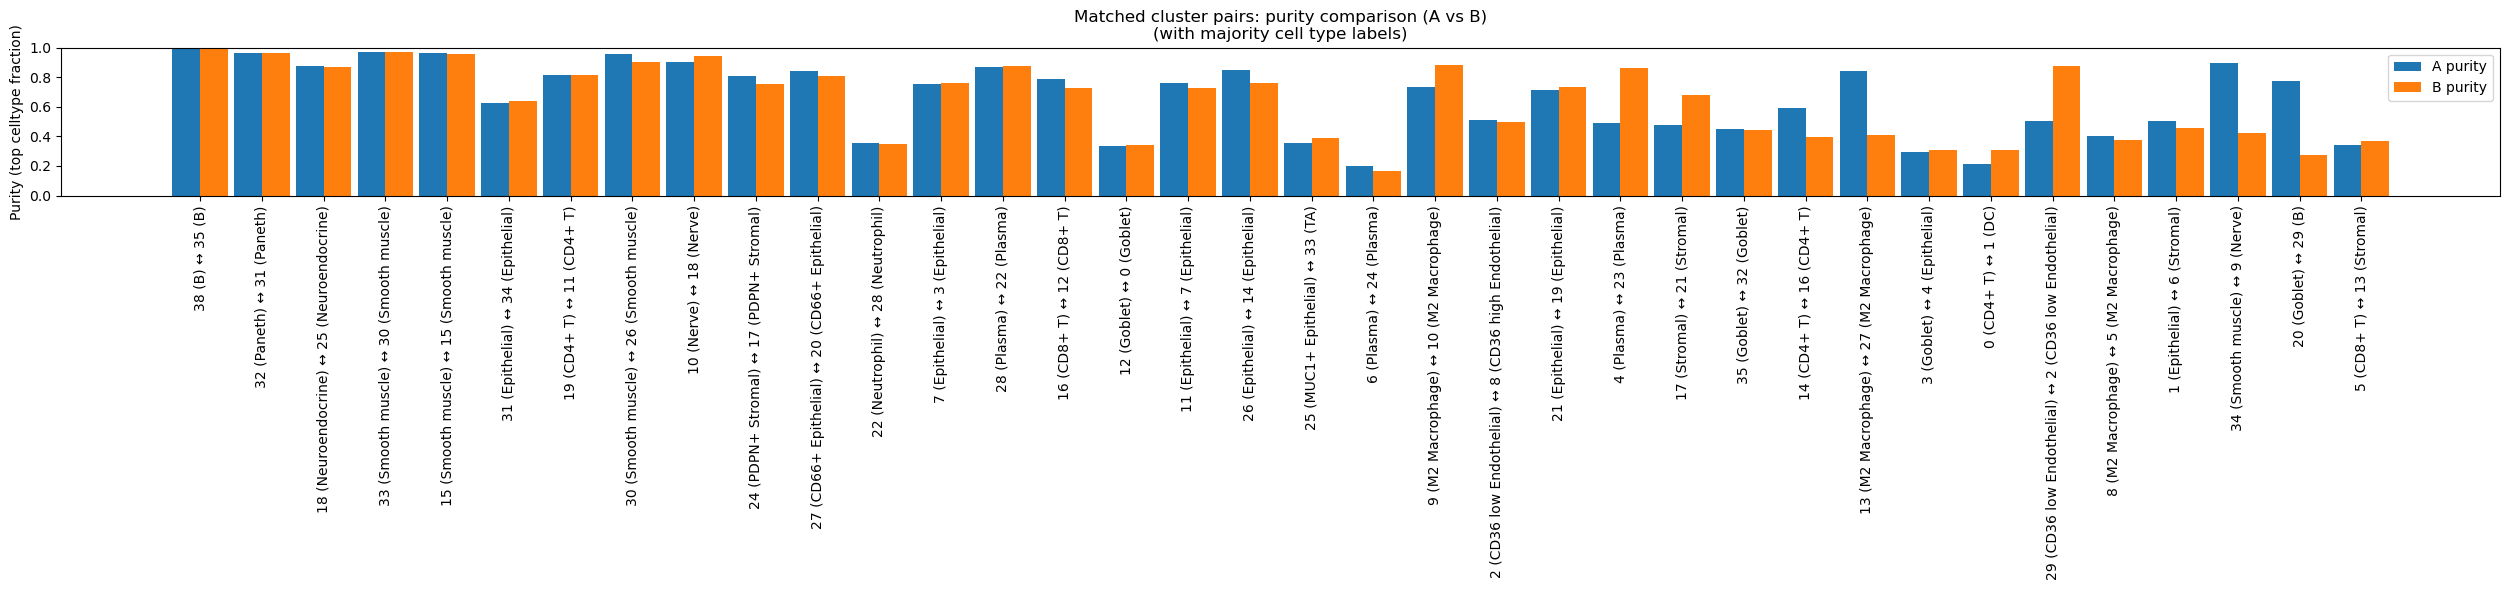

In [13]:
pairs = match_df.copy()
pairs["cluster_A"] = pairs["cluster_A"].astype(str)
pairs["cluster_B"] = pairs["cluster_B"].astype(str)

# Build a richer label:
# clusterA (top_type_A) ↔ clusterB (top_type_B)
pairs["pair"] = (
    pairs["cluster_A"] + " (" + pairs["top_celltype_A"].astype(str) + ")"
    + " ↔ " +
    pairs["cluster_B"] + " (" + pairs["top_celltype_B"].astype(str) + ")"
)

# Choose ordering: best cosine similarity first
pairs = pairs.sort_values("cosine_similarity", ascending=False).reset_index(drop=True)

# Build side-by-side bars
x = np.arange(len(pairs))
width = 0.45

fig, ax = plt.subplots(figsize=(max(12, 0.7 * len(pairs)), 6))
ax.bar(x - width/2, pairs["purity_A"].values, width, label="A purity")
ax.bar(x + width/2, pairs["purity_B"].values, width, label="B purity")

ax.set_title("Matched cluster pairs: purity comparison (A vs B)\n(with majority cell type labels)")
ax.set_ylabel("Purity (top celltype fraction)")
ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(pairs["pair"].values, rotation=90, ha="center")
ax.legend()

plt.tight_layout()
plt.show()

,pair,cluster_A,top_celltype_A,n_cells_A,purity_A,cluster_B,top_celltype_B,n_cells_B,purity_B,purity_improvement_B_minus_A,cosine_similarity
0,29 (CD36 low Endothelial) ↔ 2 (CD36 low Endoth...,29,CD36 low Endothelial,2693,0.504270,2,CD36 low Endothelial,4202,0.879343,0.375073,0.780732
1,4 (Plasma) ↔ 23 (Plasma),4,Plasma,11884,0.492595,23,Plasma,8720,0.863417,0.370822,0.940633
2,17 (Stromal) ↔ 21 (Stromal),17,Stromal,3677,0.477019,21,Stromal,1793,0.680982,0.203962,0.921317
3,9 (M2 Macrophage) ↔ 10 (M2 Macrophage),9,M2 Macrophage,3182,0.734758,10,M2 Macrophage,4239,0.884879,0.150120,0.974111
4,0 (CD4+ T) ↔ 1 (DC),0,CD4+ T,4885,0.212078,1,DC,6374,0.310951,0.098873,0.793408
5,10 (Nerve) ↔ 18 (Nerve),10,Nerve,3220,0.901242,18,Nerve,3394,0.941072,0.039830,0.999397
6,25 (MUC1+ Epithelial) ↔ 33 (TA),25,MUC1+ Epithelial,838,0.356802,33,TA,759,0.392622,0.035820,0.985100
7,5 (CD8+ T) ↔ 13 (Stromal),5,CD8+ T,7351,0.339546,13,Stromal,4607,0.368570,0.029024,0.436341
8,21 (Epithelial) ↔ 19 (Epithelial),21,Epithelial,2581,0.715614,19,Epithelial,5795,0.732183,0.016569,0.949066
9,31 (Epithelial) ↔ 34 (Epithelial),31,Epithelial,1900,0.628947,34,Epithelial,1855,0.642588,0.013640,0.999773


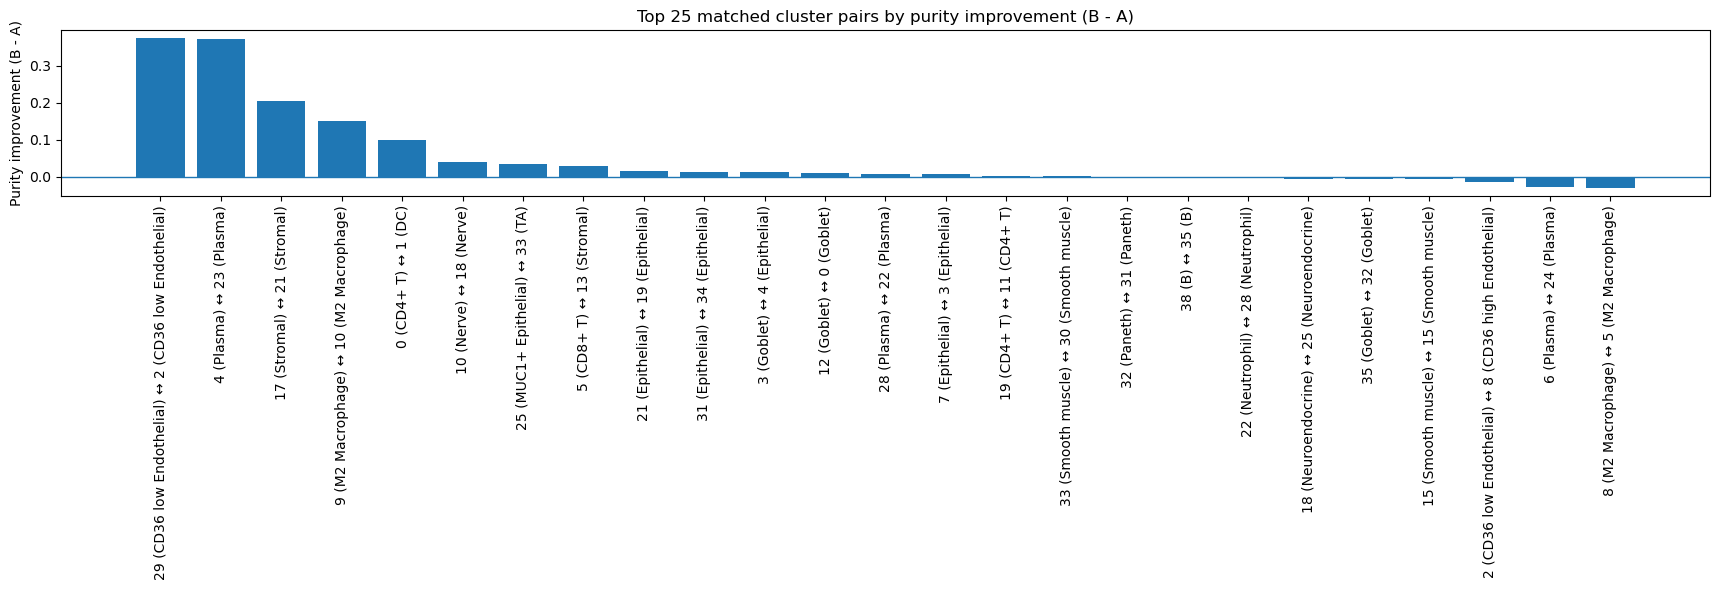

In [14]:
improve = match_df.copy()

# Ensure numeric
improve["purity_A"] = pd.to_numeric(improve["purity_A"], errors="coerce")
improve["purity_B"] = pd.to_numeric(improve["purity_B"], errors="coerce")

# Improvement = B - A (positive means improved after)
improve["purity_improvement_B_minus_A"] = improve["purity_B"] - improve["purity_A"]

# Nice label
improve["pair"] = (
    improve["cluster_A"].astype(str) + " (" + improve["top_celltype_A"].astype(str) + ")"
    + " ↔ " +
    improve["cluster_B"].astype(str) + " (" + improve["top_celltype_B"].astype(str) + ")"
)

# Order by biggest improvement (then similarity, then n_cells_B)
improve = improve.sort_values(
    ["purity_improvement_B_minus_A", "cosine_similarity", "n_cells_B"],
    ascending=[False, False, False],
).reset_index(drop=True)

cols = [
    "pair",
    "cluster_A", "top_celltype_A", "n_cells_A", "purity_A",
    "cluster_B", "top_celltype_B", "n_cells_B", "purity_B",
    "purity_improvement_B_minus_A",
    "cosine_similarity",
]
display(improve[cols].head(30))

# Optional: bar plot of top improvements
topk = 25 if len(improve) > 25 else len(improve)
plot_df = improve.head(topk)

import matplotlib.pyplot as plt

x = np.arange(topk)
fig, ax = plt.subplots(figsize=(max(12, 0.7*topk), 6))
ax.bar(x, plot_df["purity_improvement_B_minus_A"].values)

ax.axhline(0, linewidth=1)
ax.set_title(f"Top {topk} matched cluster pairs by purity improvement (B - A)")
ax.set_ylabel("Purity improvement (B - A)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["pair"].values, rotation=90)

plt.tight_layout()
plt.show()